SMS Spam Detection Using SVM

In [3]:
%pip install pandas numpy matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Import libraries

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load dataset

In [5]:
df = pd.read_csv("data/spam.csv", encoding='latin-1')

print(df.head())
print(df.info())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB

Cleaning, preprocessing

In [6]:
# Remove unnecessary columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Show cleaned dataframe
print(df.head())

# Check class distribution
print(df['label'].value_counts())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64


Label encoding and train-test split

In [7]:
from sklearn.model_selection import train_test_split

# Convert labels to numbers
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())

# Features and targets
X = df['message']
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
Training samples: 4457
Test samples: 1115


Text vectorization using CountVectorizer

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# Create vectorizer
vectorizer = CountVectorizer()

# Learn vocabulary from training data
X_train_vec = vectorizer.fit_transform(X_train)

# Transform test data using same vocabulary
X_test_vec = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Training matrix shape: (4457, 7735)
Test matrix shape: (1115, 7735)


Model training completed.
Accuracy: 0.9820627802690582

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.99      0.88      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:
[[963   2]
 [ 18 132]]


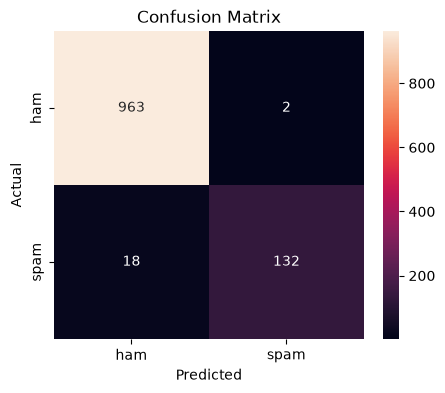

In [9]:
from sklearn.svm import LinearSVC

# Create SVM model
svm_model = LinearSVC(random_state=42)

# Train model
svm_model.fit(X_train_vec, y_train)

print("Model training completed.")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on test data
y_pred = svm_model.predict(X_test_vec)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()